# Flight Price Prediction Using Machine Learning

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Load Dataset

In [3]:
df = pd.read_csv("C:/Users/HP_OMEN/Downloads/archive/Clean_Dataset.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## Basic Data Inspection

In [4]:
print(df.shape)
print(df.info())

(300153, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None


In [5]:
print(df.isnull().sum())

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


## Exploratory Data Analysis (EDA)

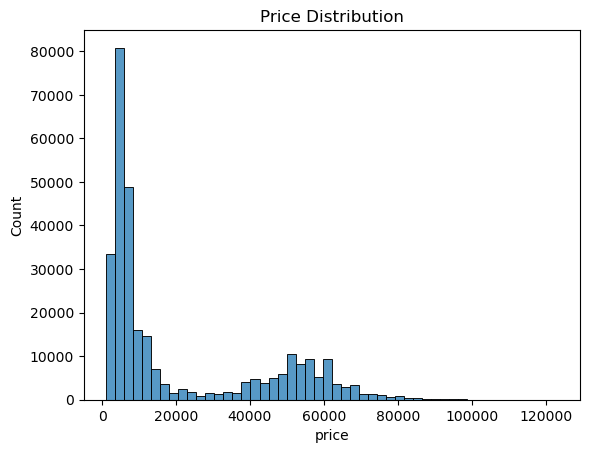

In [6]:
# Price Distribution

plt.figure()
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

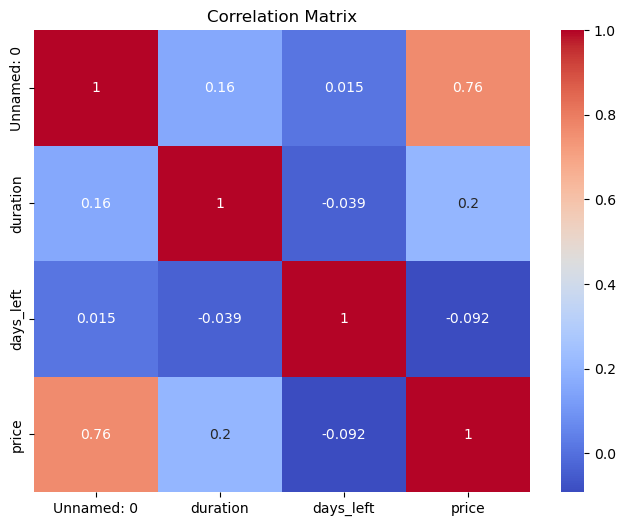

In [7]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

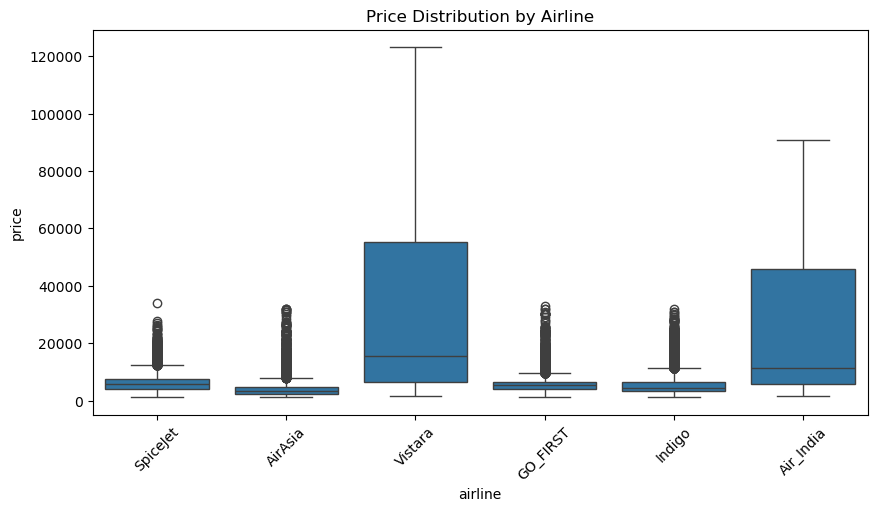

In [8]:
# Price vs Airline
plt.figure(figsize=(10,5))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Price Distribution by Airline")
plt.show()

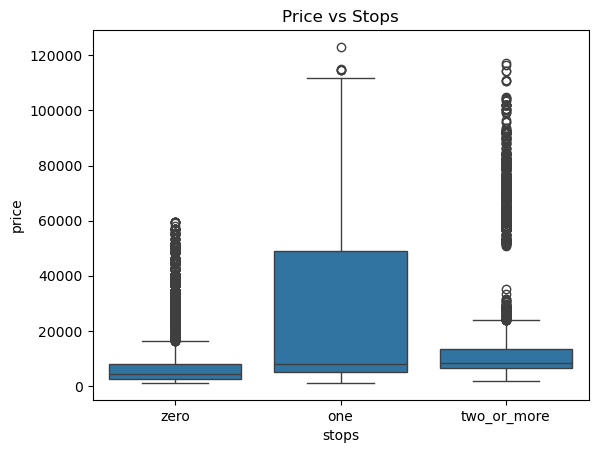

In [9]:
# Price vs Number of Stops
plt.figure()
sns.boxplot(x='stops', y='price', data=df)
plt.title("Price vs Stops")
plt.show()

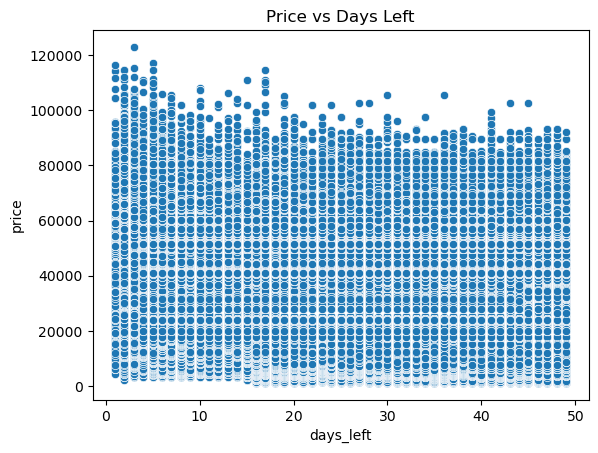

In [10]:
# Price vs Days Left
plt.figure()
sns.scatterplot(x='days_left', y='price', data=df)
plt.title("Price vs Days Left")
plt.show()

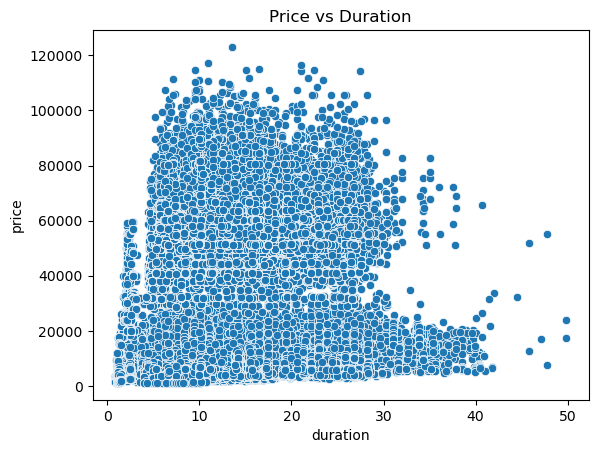

In [11]:
# Price vs Duration
plt.figure()
sns.scatterplot(x='duration', y='price', data=df)
plt.title("Price vs Duration")
plt.show()

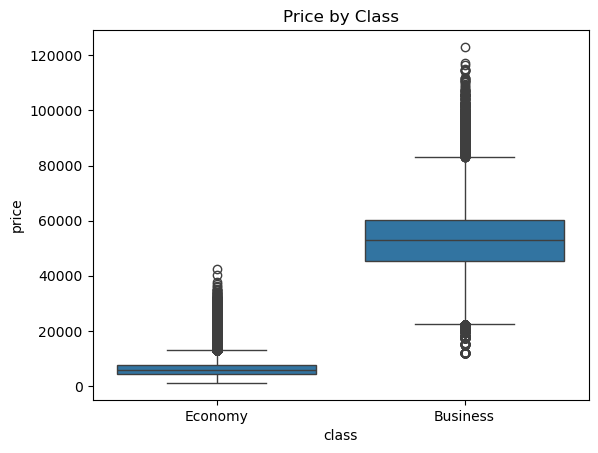

In [12]:
# Class vs Price
plt.figure()
sns.boxplot(x='class', y='price', data=df)
plt.title("Price by Class")
plt.show()

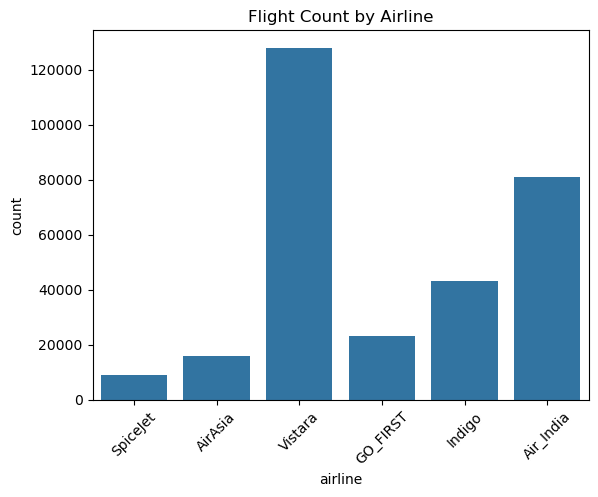

In [13]:
# Count Plot
sns.countplot(x='airline', data=df)
plt.xticks(rotation=45)
plt.title("Flight Count by Airline")
plt.show()

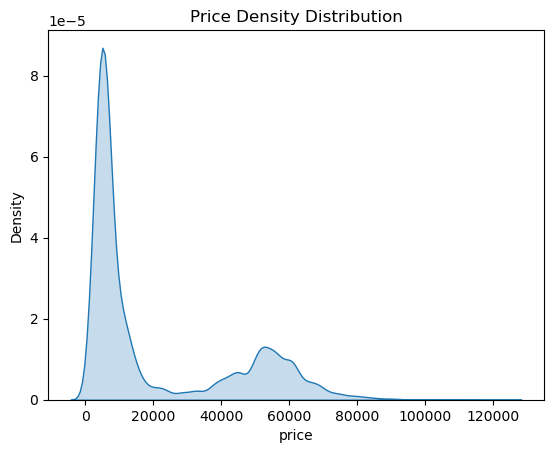

In [14]:
# KDE Plot
sns.kdeplot(df['price'], fill=True)
plt.title("Price Density Distribution")
plt.show()

## Outlier Detection

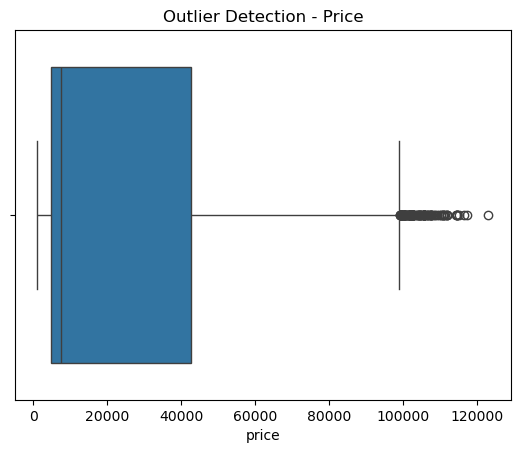

In [16]:
plt.figure()
sns.boxplot(x=df['price'])
plt.title("Outlier Detection - Price")
plt.show()
df = df[df['price'] < df['price'].quantile(0.99)]

## Data Preprocessing

In [17]:
# Drop unnecessary columns
df = df.drop(['flight'], axis=1)
df = df.drop(['Unnamed: 0'], axis=1)

## Feature Engineering

In [15]:
# Convert duration into minutes
df['duration_mins'] = df['duration'] * 60

# Create new feature: route (source to destination)
df['route'] = df['source_city'] + "_" + df['destination_city']

# Encode new feature
df['route'] = LabelEncoder().fit_transform(df['route'])

### Encode categorical features

In [19]:
categorical_cols = ['airline', 'source_city', 'destination_city',
                    'departure_time', 'arrival_time', 'stops', 'class']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

## Define Features & Target

In [20]:
X = df.drop('price', axis=1)
y = df['price']

## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1 - Linear Regression

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 4304.181500065508
RMSE: 6163.939682519452
R2 Score: 0.921412480531841


## Model 2 - Random Forest

In [37]:
rf = RandomForestRegressor(max_depth=15, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 1467.9441650294204
RMSE: 2740.283428548854
R2 Score: 0.9844679854327176


## Hyperparameter Tuning

In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

best_model = rf_random.best_estimator_

## Final Model Evaluation

In [39]:
y_pred_best = best_model.predict(X_test)

print("Tuned Model Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2 Score:", r2_score(y_test, y_pred_best))

Tuned Model Results:
MAE: 902.0733954770277
RMSE: 2223.552478517813
R2 Score: 0.9897733924987493


## Cross Validation

In [40]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation R2 Scores: [0.56290542 0.54182679 0.58727698 0.89007293 0.21320682]
Average CV Score: 0.5590577854919243


## Model Comparison

In [41]:
models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Tuned RF": best_model
}

for name, model in models.items():
    pred = model.predict(X_test)
    print(f"{name} R2:", r2_score(y_test, pred))

Linear Regression R2: 0.921412480531841
Random Forest R2: 0.9844679854327176
Tuned RF R2: 0.9897733924987493


## Feature Importance

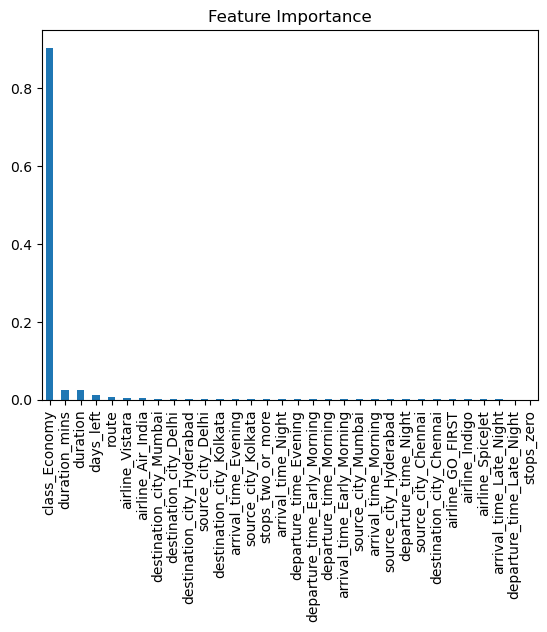

In [42]:
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

## Residual Analysis

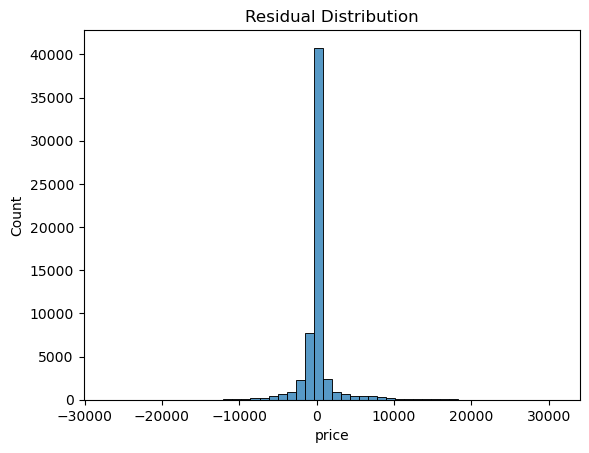

In [43]:
residuals = y_test - y_pred_best

plt.figure()
sns.histplot(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

## Save Final Model

In [44]:
import pickle

# Save model
with open("flight_price_model.pkl", "wb") as f:
    pickle.dump(best_model, f)